# <span style="color:blue"> **Análise Exploratória**</span>

## **Disciplina:** Ciência de Dados II

### **Aluno:** Mykael Querido Marinho da Silva

A ideia dessa introdução ao projeto é fazer uma análise exploratório da base de dados, por meio de estatística descritiva.

A base de dados utilizada para o projeto é a de Microdados do Enem 2024, publicados pelo Instituto Nacional de Estudos e Pesquisas Anísio Teixeira (INEP). 

Disponível em: https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados

In [20]:
# Importando bibliotecas necessárias

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


### Conhecendo os dados

Os dados do Enem são disponibilizados com granularidade por estudante, sendo cada linha da base referente às notas de um estudante.

In [2]:
# Conferir o caminho que o código está rodando
os.getcwd()

'c:\\Users\\mykaq\\Desktop\\Estudos\\Unifesp\\Ciência de Dados II\\Projeto\\cd2_analise_enem\\notebooks'

In [3]:
# Caminho relativo ao notebook
path = "../data/raw/RESULTADOS_2024.csv"

df_enem = pd.read_csv(
    path,
    sep=";",
    encoding="latin1"
)

df_enem.head()

,NU_SEQUENCIAL,NU_ANO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,...,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,206403,2024,23052929.0,2301406.0,Aratuba,23.0,CE,2.0,1.0,1.0,...,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,42103770.0,4218004.0,Tijucas,42.0,SC,4.0,1.0,1.0,...,DADABCDCECEDEBBBEBCDBADACBCADCEBEADBAECAECEDA,AACEADDDACDADECBBDBEEBDDECCBEDDCADBBDEBCEBDCEC...,DBCECEACADABBECBEDADCCDCCABBBCECEBCEADABBADDD,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,CAEDBADBEBCCEDADBAEACBCADCEDEBBEBACECEABCDDAD,EAAACDDCDADDCBDEECEECBDCDADEEBCBEBADBCEBDBDDDD...,ABBABBADDDBBCECEADCEBCCCDBADCBEDAECADACDBCECE,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,ACBCADCEDBAECEDADBADBEBCDADABCDEABCAEDEBBCECE,AACEADACDDCBEDADEEBDDBDBBCEECBDCBADDDCBDEDDCEC...,CEBCEADBBCEADDDABBABBCCDCCECEDBACADECABEDADCB,1.0,140.0,200.0,160.0,160.0,80.0,740.0
4,3148322,2024,21150354.0,2100436.0,Alto Alegre do Maranhão,21.0,MA,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Análise exploratória inicial

df_enem.shape
df_enem.columns.tolist()
df_enem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4332944 entries, 0 to 4332943
Data columns (total 42 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   NU_SEQUENCIAL           int64  
 1   NU_ANO                  int64  
 2   CO_ESCOLA               float64
 3   CO_MUNICIPIO_ESC        float64
 4   NO_MUNICIPIO_ESC        object 
 5   CO_UF_ESC               float64
 6   SG_UF_ESC               object 
 7   TP_DEPENDENCIA_ADM_ESC  float64
 8   TP_LOCALIZACAO_ESC      float64
 9   TP_SIT_FUNC_ESC         float64
 10  CO_MUNICIPIO_PROVA      int64  
 11  NO_MUNICIPIO_PROVA      object 
 12  CO_UF_PROVA             int64  
 13  SG_UF_PROVA             object 
 14  TP_PRESENCA_CN          int64  
 15  TP_PRESENCA_CH          int64  
 16  TP_PRESENCA_LC          int64  
 17  TP_PRESENCA_MT          int64  
 18  CO_PROVA_CN             float64
 19  CO_PROVA_CH             float64
 20  CO_PROVA_LC             float64
 21  CO_PROVA_MT             float64

In [ ]:
# Filtrando apenas alunos com presença confirmada

df_enem = df_enem[
    (df_enem['TP_PRESENCA_CN'] == 1) & 
    (df_enem['TP_PRESENCA_CH'] == 1) & 
    (df_enem['TP_PRESENCA_LC'] == 1) & 
    (df_enem['TP_PRESENCA_MT'] == 1)
]

In [72]:
# Definição das colunas de interesse para análise

cols = [
    "NU_SEQUENCIAL",
    "CO_ESCOLA",
    "CO_MUNICIPIO_ESC",
    "NO_MUNICIPIO_ESC",
    "SG_UF_ESC",
    "TP_DEPENDENCIA_ADM_ESC",
    "TP_LOCALIZACAO_ESC",
    "TP_SIT_FUNC_ESC",
    "NU_NOTA_MT",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_REDACAO",
    "NU_NOTA_COMP1",
    "NU_NOTA_COMP2",
    "NU_NOTA_COMP3",
    "NU_NOTA_COMP4",
    "NU_NOTA_COMP5"
]

# Editando o DataFrame para manter apenas as colunas de interesse
df_enem_filtrado = df_enem[cols]

In [74]:
# Ajustando tipos de dados

df_enem_filtrado['NU_SEQUENCIAL'] = df_enem_filtrado['NU_SEQUENCIAL'].astype(str)
df_enem_filtrado['CO_ESCOLA'] = df_enem_filtrado['CO_ESCOLA'].astype(str)
df_enem_filtrado['CO_MUNICIPIO_ESC'] = df_enem_filtrado['CO_MUNICIPIO_ESC'].astype(str)
df_enem_filtrado['SG_UF_ESC'] = df_enem_filtrado['SG_UF_ESC'].astype(str)
df_enem_filtrado['TP_DEPENDENCIA_ADM_ESC'] = df_enem_filtrado['TP_DEPENDENCIA_ADM_ESC'].astype(float)
df_enem_filtrado['TP_LOCALIZACAO_ESC'] = df_enem_filtrado['TP_LOCALIZACAO_ESC'].astype(float)
df_enem_filtrado['TP_SIT_FUNC_ESC'] = df_enem_filtrado['TP_SIT_FUNC_ESC'].astype(float)

C:\Users\mykaq\AppData\Local\Temp\ipykernel_10128\1707581436.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enem_filtrado['NU_SEQUENCIAL'] = df_enem_filtrado['NU_SEQUENCIAL'].astype(str)
C:\Users\mykaq\AppData\Local\Temp\ipykernel_10128\1707581436.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enem_filtrado['CO_ESCOLA'] = df_enem_filtrado['CO_ESCOLA'].astype(str)
C:\Users\mykaq\AppData\Local\Temp\ipykernel_10128\1707581436.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy 

In [75]:
# Estatística descritiva para colunas numéricas

df_enem_filtrado.describe()

,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,NU_NOTA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5
count,1.193432e+06,1.193432e+06,1193432.0,2.990093e+06,2.990093e+06,2.990093e+06,2.990093e+06,2.990093e+06,2.990093e+06,2.990093e+06,2.990093e+06,2.990093e+06,2.990093e+06
mean,2.363743e+00,1.044416e+00,1.0,5.270813e+02,4.940260e+02,5.142128e+02,5.266217e+02,6.346660e+02,1.212311e+02,1.466827e+02,1.198078e+02,1.309298e+02,1.160145e+02
std,8.645281e-01,2.060167e-01,0.0,1.141715e+02,7.898947e+01,9.155594e+01,6.865750e+01,2.090954e+02,3.602026e+01,4.617845e+01,4.117161e+01,4.456412e+01,6.171381e+01
min,1.000000e+00,1.000000e+00,1.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,1.000000e+00,1.0,4.313000e+02,4.315000e+02,4.502000e+02,4.867000e+02,5.200000e+02,1.000000e+02,1.200000e+02,1.000000e+02,1.200000e+02,8.000000e+01
50%,2.000000e+00,1.000000e+00,1.0,4.992000e+02,4.885000e+02,5.194000e+02,5.334000e+02,6.400000e+02,1.200000e+02,1.600000e+02,1.200000e+02,1.200000e+02,1.200000e+02
75%,2.000000e+00,1.000000e+00,1.0,6.110000e+02,5.503000e+02,5.785000e+02,5.736000e+02,8.000000e+02,1.400000e+02,1.800000e+02,1.400000e+02,1.600000e+02,1.600000e+02
max,4.000000e+00,2.000000e+00,1.0,9.619000e+02,8.672000e+02,8.197000e+02,7.958000e+02,1.000000e+03,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02


In [82]:
# Criando média geral das notas

df_enem_filtrado['NU_NOTA_MEDIA_GERAL'] = df_enem_filtrado[[
    "NU_NOTA_MT",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_REDACAO"
]].mean(axis=1)

# Criando média das objetivas (sem redação)

df_enem_filtrado['NU_NOTA_MEDIA_OBJETIVAS'] = df_enem_filtrado[[
    "NU_NOTA_MT",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC"
]].mean(axis=1)

df_enem_filtrado.head(5)

C:\Users\mykaq\AppData\Local\Temp\ipykernel_10128\1714432521.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enem_filtrado['NU_NOTA_MEDIA_GERAL'] = df_enem_filtrado[[
C:\Users\mykaq\AppData\Local\Temp\ipykernel_10128\1714432521.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enem_filtrado['NU_NOTA_MEDIA_OBJETIVAS'] = df_enem_filtrado[[


,NU_SEQUENCIAL,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,NU_NOTA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_MEDIA_GERAL,NU_NOTA_MEDIA_OBJETIVAS
0,206403,23052929.0,2301406.0,Aratuba,CE,Estadual,Urbana,1.0,427.1,436.8,377.8,423.4,300.0,80.0,60.0,60.0,80.0,20.0,393.02,416.275
1,3604651,42103770.0,4218004.0,Tijucas,SC,Privada,Urbana,1.0,689.2,521.9,601.9,605.5,920.0,160.0,200.0,200.0,180.0,180.0,667.70,604.625
2,1461268,nan,nan,NaN,nan,Desconhecido,Desconhecido,NaN,456.4,363.0,548.4,557.2,480.0,120.0,120.0,40.0,120.0,80.0,481.00,481.250
3,4301058,nan,nan,NaN,nan,Desconhecido,Desconhecido,NaN,629.1,550.7,553.8,605.9,740.0,140.0,200.0,160.0,160.0,80.0,615.90,584.875
7,140768,nan,nan,NaN,nan,Desconhecido,Desconhecido,NaN,496.7,482.7,531.6,439.2,360.0,100.0,80.0,60.0,120.0,0.0,462.04,487.550


In [83]:
# Novas estatísticas descritivas para as novas colunas

df_enem_filtrado[['NU_NOTA_MEDIA_GERAL', 'NU_NOTA_MEDIA_OBJETIVAS']].describe()

,NU_NOTA_MEDIA_GERAL,NU_NOTA_MEDIA_OBJETIVAS
count,2.990093e+06,2.990093e+06
mean,5.393216e+02,5.154855e+02
std,9.132661e+01,7.637700e+01
min,0.000000e+00,0.000000e+00
25%,4.763800e+02,4.565000e+02
50%,5.347200e+02,5.049500e+02
75%,6.021000e+02,5.675750e+02
max,8.598000e+02,8.447500e+02


In [78]:
# Ajustando tipos de dependência administrativa para categórico

df_enem_filtrado['TP_DEPENDENCIA_ADM_ESC'] = df_enem_filtrado['TP_DEPENDENCIA_ADM_ESC'].map({
    1.0: 'Federal',
    2.0: 'Estadual',
    3.0: 'Municipal',
    4.0: 'Privada'
}).fillna('Desconhecido')

C:\Users\mykaq\AppData\Local\Temp\ipykernel_10128\684372640.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enem_filtrado['TP_DEPENDENCIA_ADM_ESC'] = df_enem_filtrado['TP_DEPENDENCIA_ADM_ESC'].map({


In [79]:
# Ajustando tipos de localização para categórico

df_enem_filtrado['TP_LOCALIZACAO_ESC'] = df_enem_filtrado['TP_LOCALIZACAO_ESC'].map({
    1.0: 'Urbana',
    2.0: 'Rural'
}).fillna('Desconhecido')

C:\Users\mykaq\AppData\Local\Temp\ipykernel_10128\763613039.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enem_filtrado['TP_LOCALIZACAO_ESC'] = df_enem_filtrado['TP_LOCALIZACAO_ESC'].map({


In [84]:
# Criando dataframe para análise de média por UF
# UF diferente de nulo
df_media_uf = df_enem_filtrado['SG_UF_ESC'].isnull() == False
df_media_uf = df_media_uf.groupby('SG_UF_ESC')[['NU_NOTA_MEDIA_GERAL']].mean().reset_index()
df_media_uf = df_media_uf.rename(columns={'NU_NOTA_MEDIA_GERAL': 'MEDIA_GERAL_UF'})
df_media_uf = df_media_uf.sort_values(by='MEDIA_GERAL_UF', ascending=False)


print("Média geral por UF:")
df_media_uf

KeyError: 'SG_UF_ESC'

### Primeiros gráficos

In [40]:
# Função para plotar histogramas de notas

def plotar_histograma_notas(df, coluna, titulo="Distribuição de Notas"):
    # 1. Dicionário de Tradução (Mapeamento de nomes técnicos para exibição)
    traducoes = {
        "NU_NOTA_MEDIA_GERAL": "Média Geral",
        "NU_NOTA_MEDIA_OBJETIVAS": "Média das Provas Objetivas",
        "NU_NOTA_MT": "Nota de Matemática",
        "NU_NOTA_CH": "Nota de Ciências Humanas",
        "NU_NOTA_CN": "Nota de Ciências da Natureza",
        "NU_NOTA_LC": "Nota de Linguagens e Códigos",
        "NU_NOTA_REDACAO": "Nota da Redação"
    }
    
    # Define o label do eixo X (usa a tradução ou limpa o nome original se não encontrar)
    label_x = traducoes.get(coluna, coluna.replace('NU_NOTA_', '').replace('_', ' ').title())

    # 2. Configurações de Estilo
    sns.set_theme(style="whitegrid", context="notebook")
    plt.figure(figsize=(10, 6))
    
    # Remove nulos para o cálculo
    dados = df[coluna].dropna()
    
    # 3. Estatísticas
    media, mediana = dados.mean(), dados.median()
    moda = dados.mode()[0] if not dados.mode().empty else 0

    # 4. Gráfico
    sns.histplot(dados, binwidth=50, binrange=(0, 1000), kde=True, color="#868686", alpha=0.6)

    # 5. Linhas de Referência
    plt.axvline(media, color="#bd3e03", linestyle='--', linewidth=1.5, label=f'Média: {media:.2f}')
    plt.axvline(mediana, color="#05a10d", linestyle='-', linewidth=1.5, label=f'Mediana: {mediana:.2f}')
    plt.axvline(moda, color="#062db9", linestyle=':', linewidth=1.5, label=f'Moda: {moda:.2f}')

    # 6. Estética e Textos
    plt.title(titulo, fontsize=15, pad=20, fontweight='bold')
    plt.xlabel(label_x, fontsize=12) # Agora usando o nome amigável
    plt.ylabel("Quantidade de Alunos")
    plt.legend()
    sns.despine()

    # 7. Salvamento na pasta correta (subindo um nível a partir de 'notebooks')
    caminho_pasta = Path("..") / "outputs" / "figures"
    caminho_pasta.mkdir(parents=True, exist_ok=True)
    
    nome_arquivo = caminho_pasta / f"hist_{coluna.lower()}.png"
    plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
    
    print(f"✅ Gráfico salvo em: {nome_arquivo.resolve()}")
    plt.show()

✅ Gráfico salvo em: C:\Users\mykaq\Desktop\Estudos\Unifesp\Ciência de Dados II\Projeto\cd2_analise_enem\outputs\figures\hist_nu_nota_media_geral.png


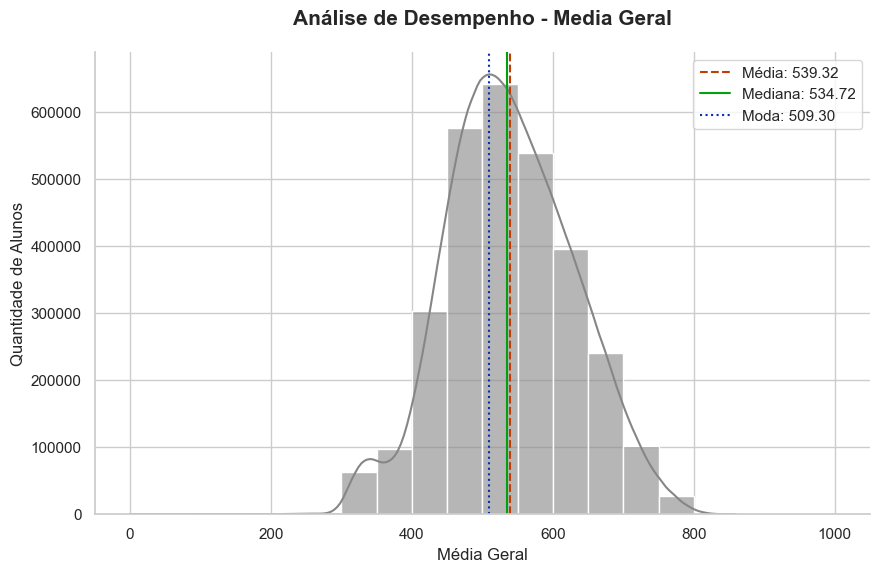

✅ Gráfico salvo em: C:\Users\mykaq\Desktop\Estudos\Unifesp\Ciência de Dados II\Projeto\cd2_analise_enem\outputs\figures\hist_nu_nota_media_objetivas.png


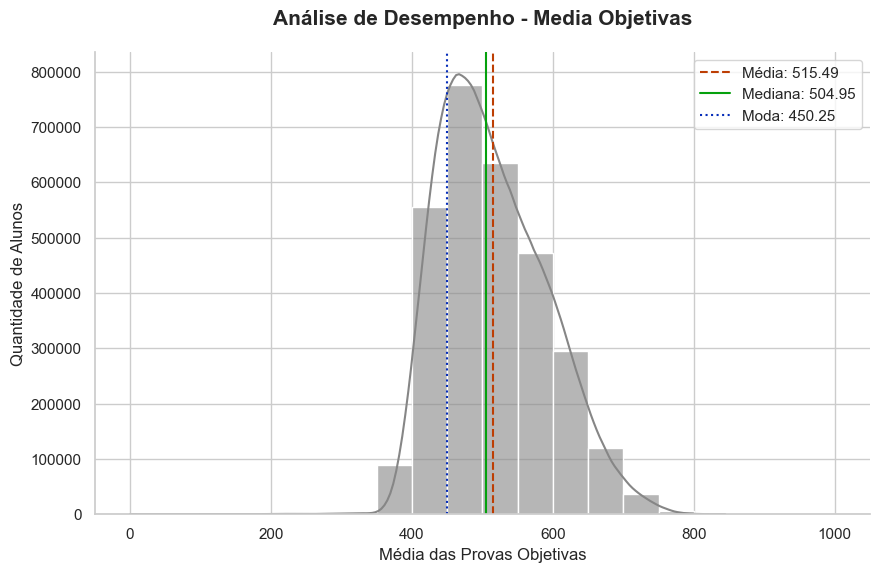

✅ Gráfico salvo em: C:\Users\mykaq\Desktop\Estudos\Unifesp\Ciência de Dados II\Projeto\cd2_analise_enem\outputs\figures\hist_nu_nota_lc.png


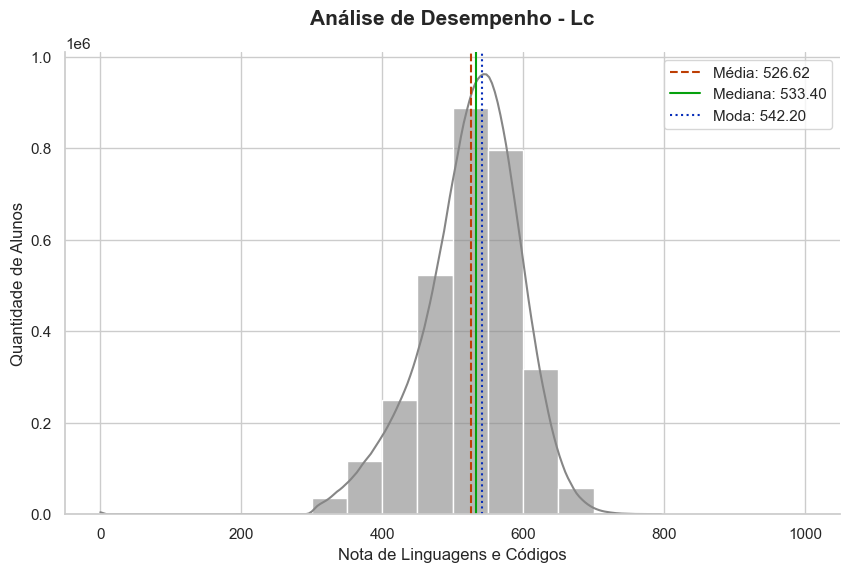

✅ Gráfico salvo em: C:\Users\mykaq\Desktop\Estudos\Unifesp\Ciência de Dados II\Projeto\cd2_analise_enem\outputs\figures\hist_nu_nota_mt.png


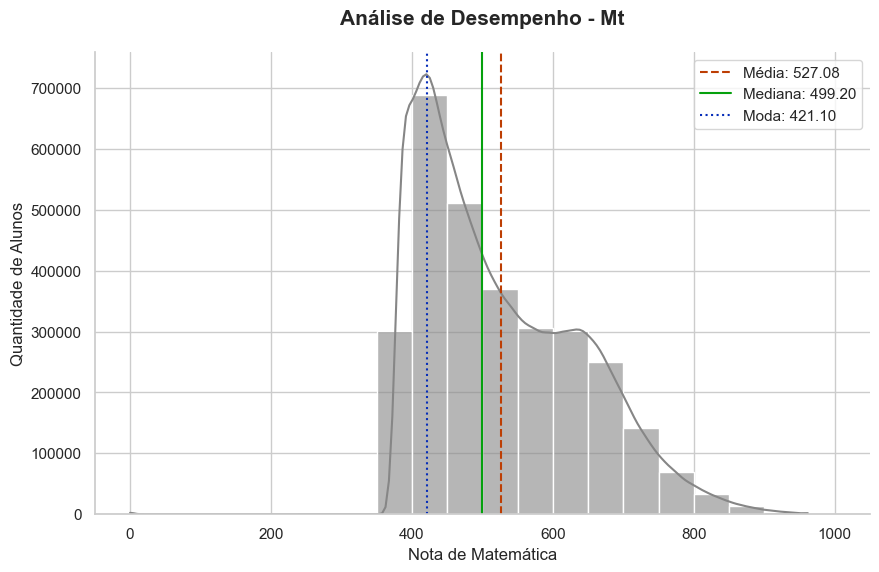

✅ Gráfico salvo em: C:\Users\mykaq\Desktop\Estudos\Unifesp\Ciência de Dados II\Projeto\cd2_analise_enem\outputs\figures\hist_nu_nota_ch.png


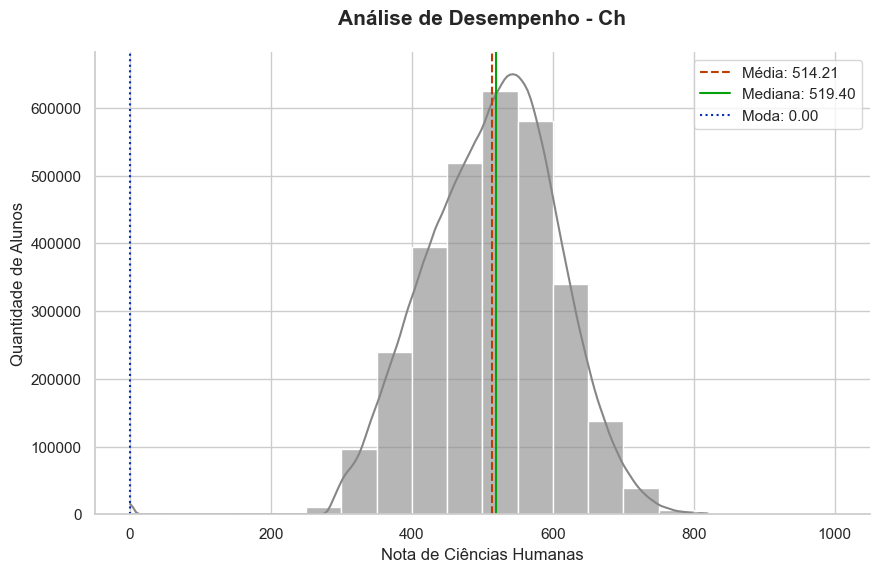

✅ Gráfico salvo em: C:\Users\mykaq\Desktop\Estudos\Unifesp\Ciência de Dados II\Projeto\cd2_analise_enem\outputs\figures\hist_nu_nota_cn.png


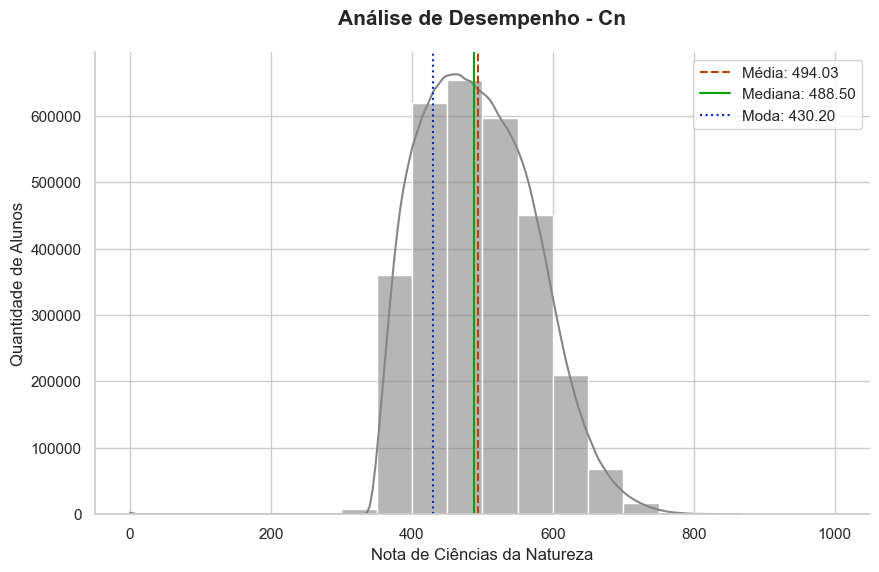

✅ Gráfico salvo em: C:\Users\mykaq\Desktop\Estudos\Unifesp\Ciência de Dados II\Projeto\cd2_analise_enem\outputs\figures\hist_nu_nota_redacao.png


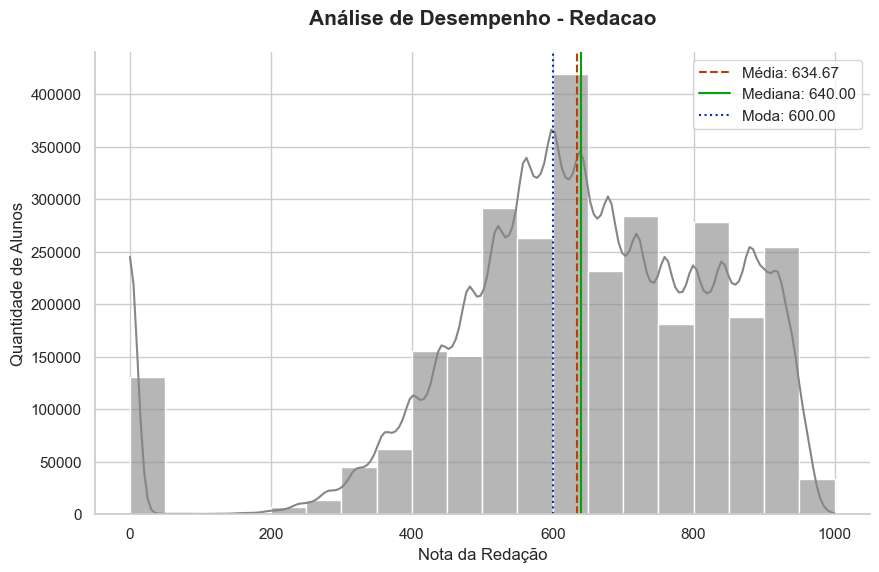

In [42]:
# Plotando o histograma para todas as notas
colunas_notas = [
    "NU_NOTA_MEDIA_GERAL",
    "NU_NOTA_MEDIA_OBJETIVAS",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_CH",
    "NU_NOTA_CN",
    "NU_NOTA_REDACAO"
]

for coluna in colunas_notas:
    plotar_histograma_notas(df_enem_filtrado, coluna, f"Análise de Desempenho - {coluna.replace('NU_NOTA_', '').replace('_', ' ').title()}")

In [54]:
# Função para plotar boxplots comparativos de notas

def plotar_boxplots_notas(df, colunas, titulo_geral="Análise Comparativa de Distribuição de Notas"):
    
    # 1. Mapeamento de nomes amigáveis
    traducoes = {
        "NU_NOTA_MT": "Matemática",
        "NU_NOTA_CH": "Ciências Humanas",
        "NU_NOTA_CN": "Ciências Natureza",
        "NU_NOTA_LC": "Linguagens",
        "NU_NOTA_REDACAO": "Redação",
        "NU_NOTA_MEDIA_GERAL": "Média Geral",
        "NU_NOTA_MEDIA_OBJETIVAS": "Média das Provas Objetivas",
    }

    # 2. Configurações da Grade (Subplots)
    # Criamos uma linha com várias colunas baseada na quantidade de matérias
    n_colunas = len(colunas)
    fig, axes = plt.subplots(1, n_colunas, figsize=(4 * n_colunas, 6), sharey=True)
    
    # Caso seja apenas uma coluna, o matplotlib não retorna uma lista, então ajustamos:
    if n_colunas == 1: axes = [axes]

    # 3. Estilo global
    sns.set_theme(style="whitegrid")

    # 4. Loop para criar cada boxplot
    for i, coluna in enumerate(colunas):
        # Filtramos zeros e nulos para não distorcer o boxplot (como vimos em CH)
        dados = df[df[coluna] > 0][coluna].dropna()
        
        sns.boxplot(y=dados, ax=axes[i], color="#4d80bb", width=0.5)
        
        # Customização de cada subplot
        label_amigavel = traducoes.get(coluna, coluna.title())
        axes[i].set_title(label_amigavel, fontsize=12, fontweight='bold')
        axes[i].set_ylabel("Nota" if i == 0 else "")
        axes[i].set_xlabel("")

    # 5. Ajustes finais e Título
    plt.suptitle(titulo_geral, fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()

    # 6. Salvamento
    caminho_pasta = Path("..") / "outputs" / "figures"
    caminho_pasta.mkdir(parents=True, exist_ok=True)
    plt.savefig(caminho_pasta / "comparativo_boxplots.png", dpi=300, bbox_inches='tight')

    plt.show()

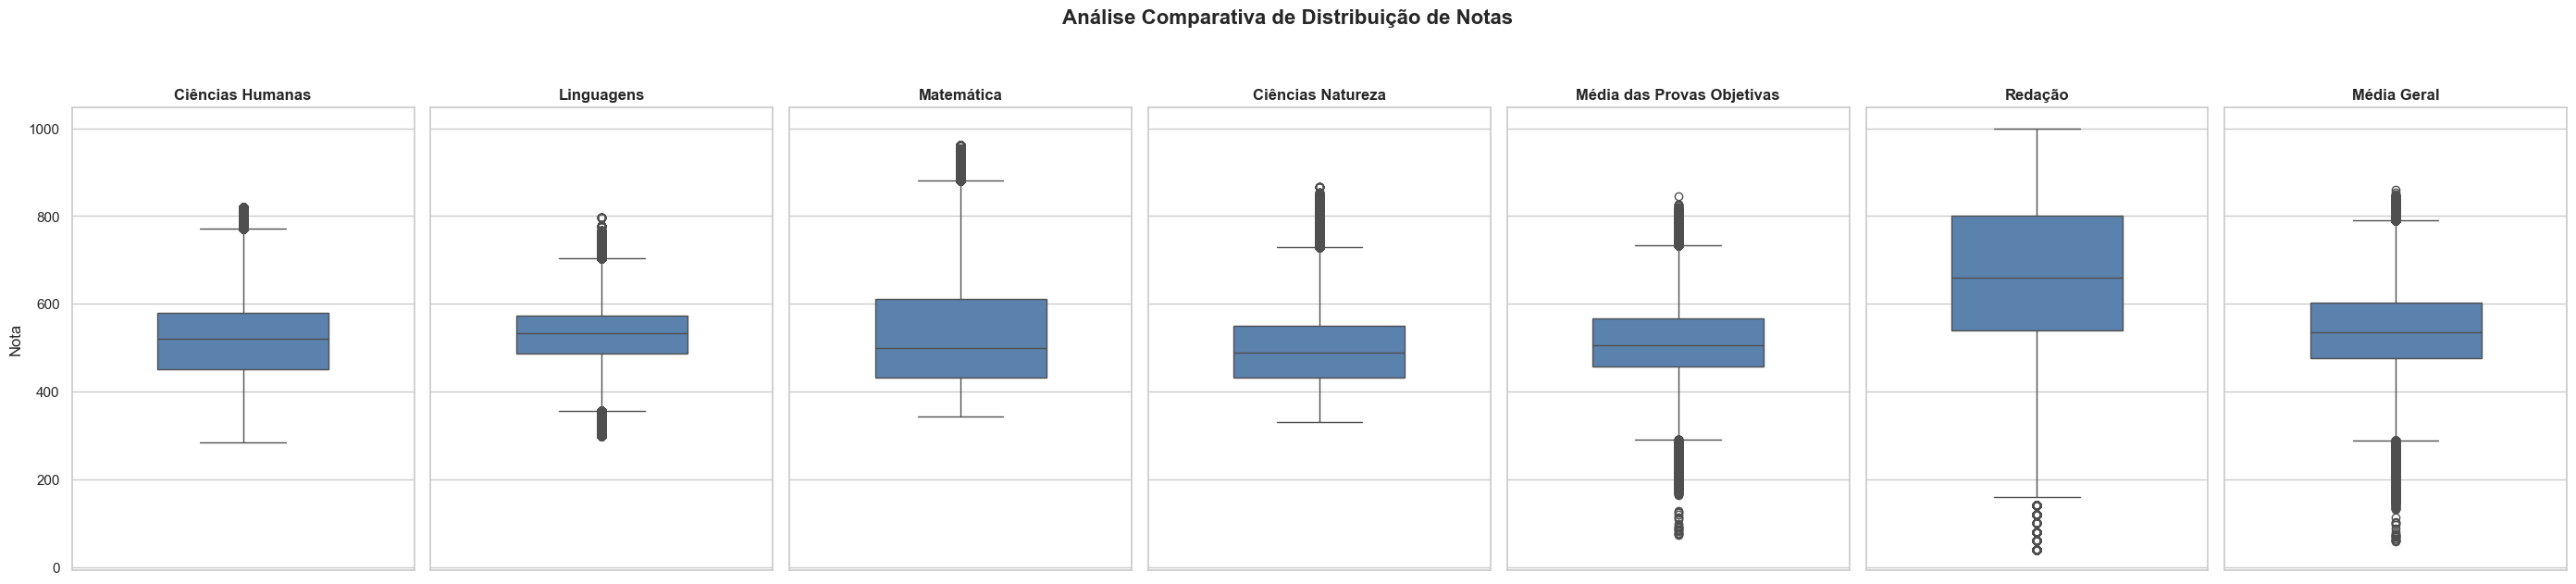

In [56]:
areas = [
    "NU_NOTA_CH", 
    "NU_NOTA_LC", 
    "NU_NOTA_MT", 
    "NU_NOTA_CN", 
    "NU_NOTA_MEDIA_OBJETIVAS", 
    "NU_NOTA_REDACAO", 
    "NU_NOTA_MEDIA_GERAL"
]

plotar_boxplots_notas(df_enem_filtrado, areas)

In [61]:
# Função para plotar boxplot comparativo por tipo de escola

def plotar_boxplot_tipo_escola(df, coluna_nota, titulo="Desempenho por Tipo de Escola"):

    # 1. Configurações de Estilo
    sns.set_theme(style="whitegrid", context="notebook")
    plt.figure(figsize=(12, 7))

    # 2. Dicionário para o Eixo Y
    traducoes = {
        "NU_NOTA_MEDIA_GERAL": "Nota Média Geral",
        "NU_NOTA_MEDIA_OBJETIVAS": "Média das Provas Objetivas",
        "NU_NOTA_MT": "Nota de Matemática",
        "NU_NOTA_CH": "Nota de Ciências Humanas",
        "NU_NOTA_CN": "Nota de Ciências da Natureza",
        "NU_NOTA_LC": "Nota de Linguagens e Códigos",
        "NU_NOTA_REDACAO": "Nota da Redação"
    }
    label_y = traducoes.get(coluna_nota, "Nota")

    # 3. Criação do Gráfico
    # Mantemos todos os dados originais, removendo apenas NaN para o Seaborn não reclamar
    ax = sns.boxplot(
        x="TP_DEPENDENCIA_ADM_ESC", 
        y=coluna_nota, 
        data=df.dropna(subset=[coluna_nota, "TP_DEPENDENCIA_ADM_ESC"]), 
        palette="Set2",
        width=0.6,
        fliersize=3
    )

    # 4. Ajustes Estéticos
    plt.title(f"{titulo}\n({label_y})", fontsize=15, pad=20, fontweight='bold')
    plt.xlabel("Dependência Administrativa", fontsize=12)
    plt.ylabel(label_y, fontsize=12)
    plt.ylim(-50, 1050) 
    sns.despine()

    # 5. Salvamento na pasta correta
    caminho_pasta = Path("..") / "outputs" / "figures"
    caminho_pasta.mkdir(parents=True, exist_ok=True)
    
    nome_arquivo = caminho_pasta / f"boxplot_tipo_escola_{coluna_nota.lower()}.png"
    plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
    
    print(f"✅ Boxplot salvo em: {nome_arquivo.resolve()}")
    plt.show()

C:\Users\mykaq\AppData\Local\Temp\ipykernel_10128\3968900654.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


✅ Boxplot salvo em: C:\Users\mykaq\Desktop\Estudos\Unifesp\Ciência de Dados II\Projeto\cd2_analise_enem\outputs\figures\boxplot_tipo_escola_nu_nota_lc.png


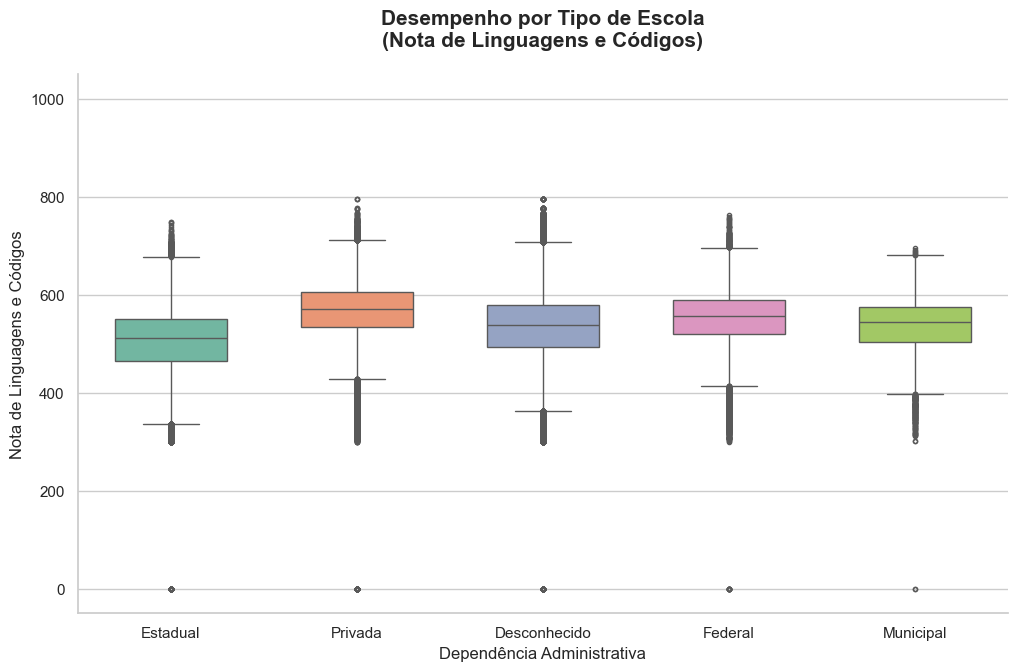

In [67]:
plotar_boxplot_tipo_escola(df_enem_filtrado, "NU_NOTA_LC")